## Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


# sklearn functions for evaluating regressors
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, max_error, root_mean_squared_error, PredictionErrorDisplay 

# dummy models for baseline
from sklearn.dummy import DummyRegressor


## Preparing the data

In [5]:
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')
#df = pd.read_csv("DKHousingPricesSample100k.csv")

In [6]:
print(df["date"].min(), "to", df["date"].max())

1992-01-05 00:00:00 to 2024-10-26 00:00:00


In [7]:
#Drop all rows with na in the sqm column
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


#### Quarter skal laves til en int istedet for datetime

In [8]:
# Brug denne for hele parquet datasættet
#Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")
df["zip_code"] = df["zip_code"].astype("category")

In [9]:
#Brug denne for 100KSample
# Convert 'quarter' strings like '2024Q3' into a numeric period representation
# Inspect current dtype and a few values
#print('quarter dtype:', df['quarter'].dtype)
#print(df['quarter'].head())
# Create a PeriodIndex with quarterly frequency, keep the Period object in a helper column
#df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
# Option A: use integer period ordinal (small integer per quarter) — convenient for regression
#df['quarter'] = df['quarter_period'].astype('int')
# Option B (alternative): convert to a timestamp for the quarter start (datetime)
# df['quarter'] = df['quarter_period'].to_timestamp()
#df.head()


### Make dummy variables

In [10]:
# We set drop_first=True to avoid the dummy variable trap
df = df.sample(frac=0.1, random_state=42).copy()
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "area", "nom_interest_rate%", "dk_ann_infl_rate%", "yield_on_mortgage_credit_bonds%"]], drop_first=True)
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,...,zip_code_9981,zip_code_9982,zip_code_9990,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
465021,199,1974,5,129.0,0.00,0.76,1.35,False,False,False,...,False,False,False,False,False,False,True,False,False,False
742767,181,1968,6,148.0,0.00,0.45,2.78,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1167754,139,2006,3,128.0,2.00,1.15,5.26,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1051169,149,2003,5,149.0,3.75,1.69,5.70,False,False,False,...,False,False,False,False,False,False,False,False,False,True
412051,201,1968,4,86.0,0.00,0.42,1.10,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [11]:
X = X[["area_Capital, Copenhagen", "sqm", "yield_on_mortgage_credit_bonds%", "quarter", "no_rooms", "year_build", "nom_interest_rate%", "dk_ann_infl_rate%", "house_type_Summerhouse", "area_South jutland", "house_type_Villa", "house_type_Farm", "zip_code_2900"]]
y = df["purchase_price"]
X.shape, y.shape
X.head()

,"area_Capital, Copenhagen",sqm,yield_on_mortgage_credit_bonds%,quarter,no_rooms,year_build,nom_interest_rate%,dk_ann_infl_rate%,house_type_Summerhouse,area_South jutland,house_type_Villa,house_type_Farm,zip_code_2900
465021,False,129.0,1.35,199,5,1974,0.00,0.76,False,False,True,False,False
742767,False,148.0,2.78,181,6,1968,0.00,0.45,False,False,True,False,False
1167754,False,128.0,5.26,139,3,2006,2.00,1.15,False,False,False,False,False
1051169,False,149.0,5.70,149,5,2003,3.75,1.69,False,True,True,False,False
412051,False,86.0,1.10,201,4,1968,0.00,0.42,False,False,False,False,False


### Training and test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Creating a baseline

This baselines is based on the mean value from the dataset

In [13]:
dm = DummyRegressor(strategy='mean')
dm.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


In [14]:
dm_y_pred = dm.predict(X_test)

In [15]:
print("Score on training set: {:.3f}".format(dm.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(dm.score(X_test, y_test)))

Score on training set: 0.000
Score on test set: -0.000


## Linear Regression Model

Make the training and testing split

In [16]:
# Create and fit the model
lr = LinearRegression()
lr_y_pred = lr.fit(X_train, y_train).predict(X_test)

In [17]:
#Evaluate the model
print("Score on training set: {:.3f}".format(lr.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(lr.score(X_test, y_test)))

Score on training set: 0.319
Score on test set: 0.325


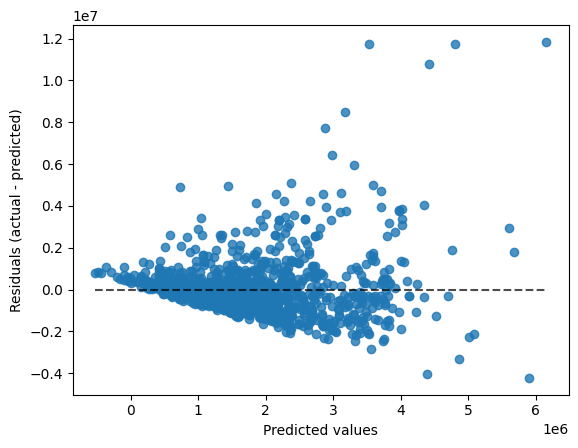

In [19]:
display = PredictionErrorDisplay.from_predictions(y_test, lr_y_pred)

## Lasso Regression

In [20]:
lasso = Lasso()
lasso_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5)
lasso_pred = lasso_grid.fit(X_train, y_train).predict(X_test)

In [21]:
#Evaluate the model
print("Score on training set: {:.3f}".format(lasso_grid.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(lasso_grid.score(X_test, y_test)))

Score on training set: 0.319
Score on test set: 0.325


## Polynomial Regression Model

We use the code below to create polynomial features on the training data to the degree of 5. 

In [22]:
# Let's try with degree 2 instead of 3 to reduce memory usage
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Only transform, don't fit again

In [23]:
# Create and fit the model
poly_lr = LinearRegression()
pr_y_pred = poly_lr.fit(X_train_poly,y_train).predict(X_test_poly)

Evaluating the model

In [24]:
print("Score on training set: {:.3f}".format(poly_lr.score(X_train_poly, y_train)))
print("Score on test set: {:.3f}".format(poly_lr.score(X_test_poly, y_test)))

Score on training set: 0.425
Score on test set: 0.417


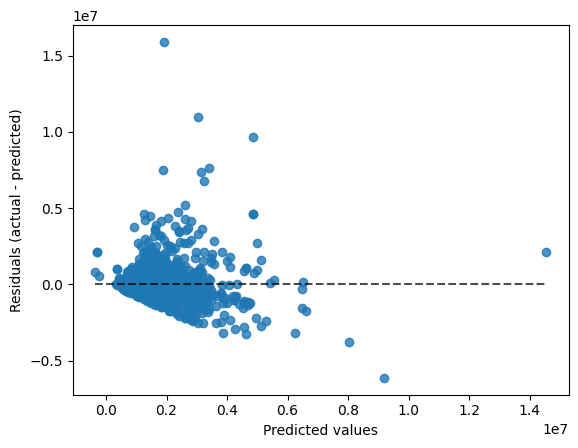

In [25]:
display = PredictionErrorDisplay.from_predictions(y_test, pr_y_pred)

## Grid Search CV

In [ ]:
# Here we set up a grid search to find the best polynomial degree for our features.
# We define a parameter grid with degrees from 1 to 5.
param_grid = {
    'poly_features__degree': [1, 2, 3, 4, 5]
}

# create the pipeline with PolynomialFeatures and LinearRegression
model = Pipeline([
    ('poly_features', PolynomialFeatures()),
    ('lin_reg', LinearRegression())
])

# set up GridSearchCV with the model and parameter grid. r2 is used as the scoring metric, and n_jobs=-1 allows for parallel processing across all available CPU cores.
grid_search = GridSearchCV(model, param_grid, scoring='r2', n_jobs=-1)

# fit the grid search to the training data
grid_search.fit(X_train, y_train)

# retrieve and print the scores for each iteration
cv_results = grid_search.cv_results_
for mean_score, params in zip(cv_results["mean_test_score"], cv_results["params"]):
    print(f"Mean R-squared for {params}: {mean_score}")

# retrieve the best hyperparameters and the corresponding best estimator
best_degree = grid_search.best_params_['poly_features__degree']
best_model = grid_search.best_estimator_

# print the best hyperparameters
print(f"Best Polynomial Degree: {best_degree}")

# evaluate the best model on the test data
test_score = best_model.score(X_test, y_test)
print(f"Test R-squared with best model: {test_score}")

PicklingError: Could not pickle the task to send it to the workers.

## KNN Model

Fitting a KNeighborsRegressor and defining it as knn.

In [27]:
knn = KNeighborsRegressor()
knn_y_pred = knn.fit(X_train, y_train).predict(X_test)

In [28]:
# print scores
print("Score on training set: {:.3f}".format(knn.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(knn.score(X_test, y_test)))

Score on training set: 0.426
Score on test set: 0.138


Using StandardScaler to standardize the scales of attributes.

In [29]:
scaler = StandardScaler() # define the scaler
X_train_scaled = scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_scaled = scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_scaled.

In [30]:
knn_scaled = KNeighborsRegressor()
knn_standard_y_pred = knn_scaled.fit(X_train_scaled, y_train).predict(X_test_scaled)

In [31]:
print("Score on training set: {:.3f}".format(knn_scaled.score(X_train_scaled, y_train)))
print("Score on test set: {:.3f}".format(knn_scaled.score(X_test_scaled, y_test)))

Score on training set: 0.595
Score on test set: 0.384


Applying RobustScaler.

In [32]:
robust_scaler = RobustScaler() # define the scaler
X_train_robust = robust_scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_robust = robust_scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_robust.

In [33]:
knn_robust = KNeighborsRegressor()
knn_robust_y_pred = knn_robust.fit(X_train_robust, y_train).predict(X_test_robust)

In [34]:
print("Score on training set: {:.3f}".format(knn_robust.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(knn_robust.score(X_test_robust, y_test)))

Score on training set: 0.591
Score on test set: 0.375


Creating a boxplot.

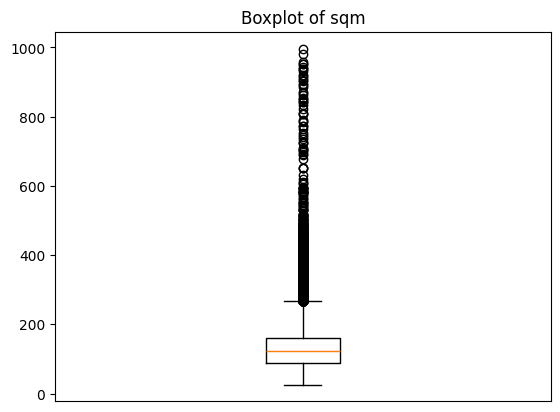

In [41]:
plt.boxplot(df['sqm'])
plt.title('Boxplot of sqm')
plt.xticks([])  
plt.show()

Setting up a parameter grid.

In [42]:
param_grid = {
    'n_neighbors': [1, 5, 10, 20, 30, 40, 50, 60], # what should we set k to? 
    'weights': ['uniform', 'distance'], # uniform weighting vs. distance weighting
    'p': [1, 2], # 1 for manhattan vs. 2 for euclidean distance
}

Using GridSearchCV.

In [43]:
grid_search = GridSearchCV(estimator=knn_robust,  # the model being tuned
                           param_grid=param_grid,  # dictionary of parameter values to search over
                           cv=5,  # number of folds to use
                           scoring='r2',  # evaluation metric
                           return_train_score=True,  # whether to return training scores in the output.
                           verbose=3)  # controls the verbosity of the output (i.e., how much output to print)

# fit the model with training data X_train_robust and target y_train
grid_search.fit(X_train_robust, y_train)  

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=0.998, test=-0.001) total time=   0.6s
[CV 2/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=0.998, test=0.025) total time=   0.6s
[CV 3/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=0.997, test=0.035) total time=   0.6s
[CV 4/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=0.998, test=-0.023) total time=   0.5s
[CV 5/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=0.997, test=0.089) total time=   0.5s
[CV 1/5] END n_neighbors=1, p=1, weights=distance;, score=(train=0.998, test=-0.001) total time=   0.5s
[CV 2/5] END n_neighbors=1, p=1, weights=distance;, score=(train=0.998, test=0.025) total time=   0.5s
[CV 3/5] END n_neighbors=1, p=1, weights=distance;, score=(train=0.997, test=0.035) total time=   0.5s
[CV 4/5] END n_neighbors=1, p=1, weights=distance;, score=(train=0.998, test=-0.023) total time=   0.5s
[CV 5/5] END

KeyboardInterrupt: 

In [ ]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

In [ ]:
best_knn = grid_search.best_estimator_
print("Score on training set: {:.3f}".format(best_knn.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(best_knn.score(X_test_robust, y_test)))

Using GridSearchCV with scaling.

In [ ]:
# define the pipeline with a placeholder scaler and the KNN regressor
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Placeholder scaler
    ('knn', KNeighborsRegressor())
])

# define the parameter grid to include different scalers and KNN parameters
param_grid = {
    'scaler': [StandardScaler(),  RobustScaler(), 'passthrough'],  # different scaling methods (`passthrough` means no scaling)
    'knn__n_neighbors': [3, 6, 12, 24, 48, 96],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}

# set up GridSearchCV with the pipeline and parameter grid
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    return_train_score=True,
    verbose=3
)

#fit the model with the original training data (without prior scaling)
grid_search.fit(X_train, y_train)

In [ ]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

## Random Forest Regressor

In [ ]:
# Random Forest – lidt lettere at træne, stadig god performance
rf = RandomForestRegressor(
    n_estimators=150,        # ned fra 500 → meget hurtigere
    max_depth=20,            # begrænser dybde → hurtigere, mindre overfitting
    min_samples_leaf=5,      # gør træerne lidt grovere → hurtigere, mere robust
    max_features="sqrt",     # færre features pr. split → hurtigere
    n_jobs=-1,
    random_state=42,
)

In [ ]:
# Træn modellen
rf.fit(X_train, y_train)
rf_y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predictions
rf_y_pred_train = rf.predict(X_train)
rf_y_pred_test  = rf.predict(X_test)

# Metrics
r2_tr = r2_score(y_train, rf_y_pred_train)
r2_te = r2_score(y_test, rf_y_pred_test)
mae   = mean_absolute_error(y_test, rf_y_pred_test)
rmse  = mean_squared_error(y_test, rf_y_pred_test) ** 0.5

print("Random Forest performance:")
print(f"Train R^2: {r2_tr:.3f}")
print(f"Test  R^2: {r2_te:.3f}")
print(f"MAE:       {mae:,.0f} kr.")
print(f"RMSE:      {rmse:,.0f} kr.")

Random Forest performance:
Train R^2: 0.601
Test  R^2: 0.491
MAE:       763,166 kr.
RMSE:      1,275,071 kr.


## Evaluation
This will be done based on MAE, MAPE, MSE, RMSE and Max

In [ ]:
# this is a function that takes actual y values (y_true) and predicted y values (y_pred) and calculates MAE, MAPE, MSE, and RMSE
def get_metrics(y_true, y_pred):
    
    # MAE: the average of the absolute differences between the actual values and the predicted values
    mae = mean_absolute_error(y_true, y_pred)
    
    # MAPE: the average absolute percentage difference between the actual and predicted values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # MSE: the average of the squared differences between the actual values and the predicted values
    mse = mean_squared_error(y_true, y_pred)
    
    # RMSE: the square root of MSE
    rmse = mean_squared_error(y_true, y_pred)

    # Max error: the average absolute percentage difference between the actual and predicted values
    max = max_error(y_true, y_pred)
    
    # return all four metrics
    return mae, mape, mse, rmse, max

In [ ]:
# calculate the metrics for each model using our `get_metrics` function.
dm_metrics = get_metrics(y_test, dm_y_pred)  # for dummy regressor
lr_metrics = get_metrics(y_test, lr_y_pred)  # for linear regression
pr_metrics = get_metrics(y_test, pr_y_pred)  # for linear regression
lasso_metrics = get_metrics(y_test, lasso_pred)  # for lasso regression
kn_metrics = get_metrics(y_test, knn_y_pred)  # for KNN regressor
kn_standard_metrics = get_metrics(y_test, knn_standard_y_pred)  # for KNN regressor with standard scaling
kn_robust_metrics = get_metrics(y_test, knn_robust_y_pred)  # for KNN regressor with robust scaling
rf_metrics = get_metrics(y_test, rf_y_pred)  # for random forest regressor

In [ ]:
# create a dataframe (table) to store and display the computed metrics where each row represents a different model and each column represents a different metric
results = pd.DataFrame({
    'Model': ['Dummy', 'Linear Regression', 'PR', 'Lasso', 'kn', 'kn_standard', 'kn_robust', 'RF'],  # model names
    'MAE': [dm_metrics[0], lr_metrics[0], pr_metrics[0], lasso_metrics[0], kn_metrics[0], kn_standard_metrics[0], kn_robust_metrics[0], rf_metrics[0]],  # MAE values for each model
    'MAPE': [dm_metrics[1], lr_metrics[1], pr_metrics[1], lasso_metrics[1], kn_metrics[1], kn_standard_metrics[1], kn_robust_metrics[1], rf_metrics[1]],  # MAPE values for each model
    'MSE': [dm_metrics[2], lr_metrics[2], pr_metrics[2], lasso_metrics[2], kn_metrics[2], kn_standard_metrics[2], kn_robust_metrics[2], rf_metrics[2]],  # MSE values for each model
    'RMSE': [dm_metrics[3], lr_metrics[3], pr_metrics[3], lasso_metrics[3], kn_metrics[3], kn_standard_metrics[3], kn_robust_metrics[3], rf_metrics[3]], # RMSE values for each model
    'Max': [dm_metrics[4], lr_metrics[4], pr_metrics[4], lasso_metrics[4], kn_metrics[4], kn_standard_metrics[4], kn_robust_metrics[4], rf_metrics[4]] # Max error values for each model

})

# display results
results

### Results
**Mean Absolute Error (MAE):**

PR performs best (lowest MAE: 808,086), followed by Linear Regression (916,957), and Dummy (1,186,556).
PR reduces MAE by ~12% compared to Linear Regression and ~32% compared to Dummy.



**Mean Absolute Percentage Error (MAPE):**

PR has the lowest MAPE (0.631), indicating better relative accuracy.
Linear Regression (0.737) and Dummy (1.083) perform worse.



**Mean Squared Error (MSE) and Root Mean Squared Error (RMSE):**

PR has the lowest MSE and RMSE, suggesting it handles large errors better than the other models.
Dummy has the highest MSE/RMSE, as expected.



**Max Error:**

PR has the highest max error (45,704,040), but this is likely an outlier and does not reflect overall performance.
Linear Regression has the lowest max error (38,035,220).